In [1]:
pip install numpy matplotlib scipy

  Using cached numpy-2.4.4-cp311-cp311-win_amd64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.10.8-cp311-cp311-win_amd64.whl.metadata (52 kB)
  Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp311-cp311-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp311-cp311-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached numpy-2.4.4-cp311-cp311-win_amd64.whl (12.6 MB)
Using cached matplotlib-3.10.8-cp311-cp311-win_amd64.whl (8.1 MB)
Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl (36.6 MB)
Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl (225 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp311-cp311-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.5.0-cp311-cp311-win_amd64.wh

1. To develop a program and simulate the Pulse Amplitude Modulation (PAM) signal and analyze its waveform.

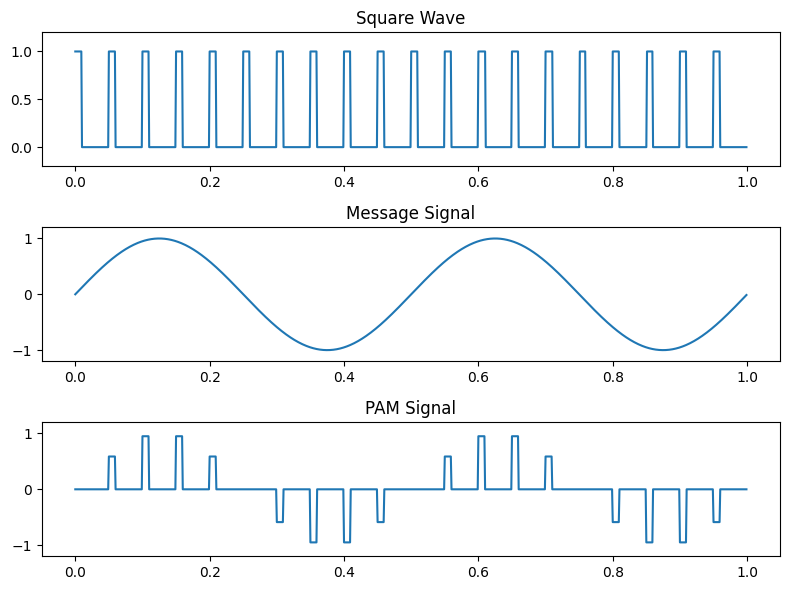

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Parameters
fc, fm, fs, t, duty = 20, 2, 1000, 1, 20

# Time vector
n = np.arange(0, t, 1/fs)

# Square wave (0 or 1)
s = (signal.square(2 * np.pi * fc * n, duty/100) + 1) / 2

# Message signal
m = np.sin(2 * np.pi * fm * (n - 1))

# PAM generation
period = int(fs / fc)
on_samples = int(np.ceil(period * duty / 100))

pam = np.zeros_like(n)

for i in range(0, len(n), period):
    pam[i:i+on_samples] = m[i]

# Plotting
plt.figure(figsize=(8, 6))

plt.subplot(3,1,1)
plt.plot(n, s)
plt.ylim([-0.2, 1.2])
plt.title("Square Wave")

plt.subplot(3,1,2)
plt.plot(n, m)
plt.ylim([-1.2, 1.2])
plt.title("Message Signal")

plt.subplot(3,1,3)
plt.plot(n, pam)
plt.ylim([-1.2, 1.2])
plt.title("PAM Signal")

plt.tight_layout()
plt.show()

2. To design a program and simulate the Amplitude Shift Keying (ASK) modulation technique.

Binary Information at transmitter: [1 0 1 0 1 0 1 0 1]
Binary Information at Receiver: [1 0 1 0 1 0 1 0 1]


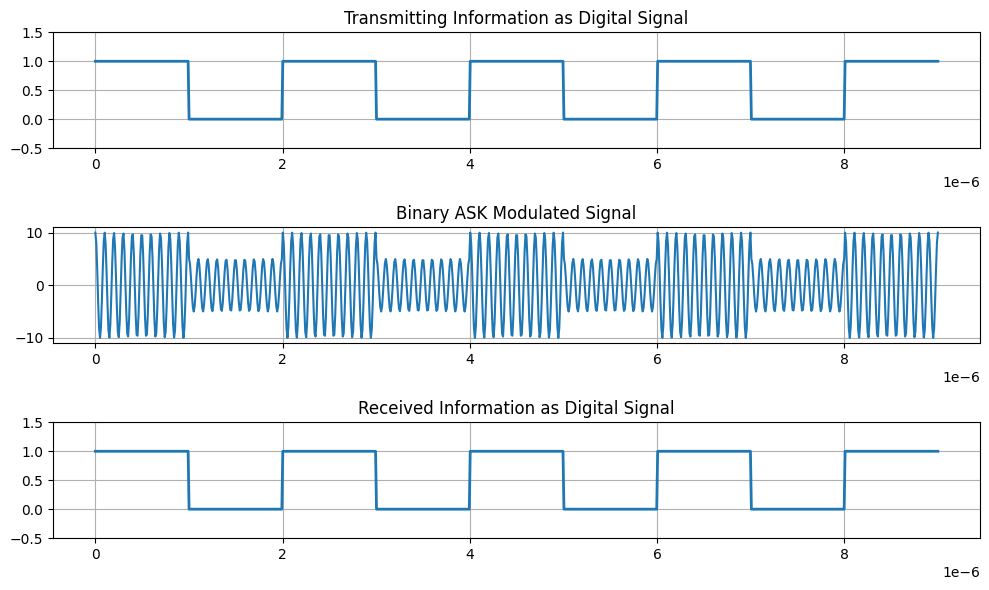

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ── Input Binary Data ─────────────────────────────
x = np.array([1,0,1,0,1,0,1,0,1])
bp = 1e-6   # bit period

print("Binary Information at transmitter:", x)

# ── Digital Signal (Transmitter) ──────────────────
samples_per_bit = 100
bit = np.repeat(x, samples_per_bit)

t1 = np.linspace(0, bp*len(x), len(bit))

# ── ASK Modulation ────────────────────────────────
A1, A2 = 10, 5
br = 1 / bp
f = br * 10

t2 = np.linspace(0, bp, 100)
m = []

for bit_val in x:
    if bit_val == 1:
        y = A1 * np.cos(2*np.pi*f*t2)
    else:
        y = A2 * np.cos(2*np.pi*f*t2)
    m.extend(y)

m = np.array(m)
t3 = np.linspace(0, bp*len(x), len(m))

# ── ASK Demodulation ──────────────────────────────
mn = []
for i in range(0, len(m), len(t2)):
    segment = m[i:i+len(t2)]
    carrier = np.cos(2*np.pi*f*t2)
    z = np.trapezoid(segment * carrier, t2)
    
    if (2*z/bp) > 7.5:
        mn.append(1)
    else:
        mn.append(0)

mn = np.array(mn)
print("Binary Information at Receiver:", mn)

# ── Reconstructed Digital Signal ──────────────────
bit_rec = np.repeat(mn, samples_per_bit)
t4 = np.linspace(0, bp*len(mn), len(bit_rec))

# ── Plotting ─────────────────────────────────────
plt.figure(figsize=(10,6))

plt.subplot(3,1,1)
plt.plot(t1, bit, linewidth=2)
plt.title("Transmitting Information as Digital Signal")
plt.ylim([-0.5, 1.5])
plt.grid()

plt.subplot(3,1,2)
plt.plot(t3, m)
plt.title("Binary ASK Modulated Signal")
plt.grid()

plt.subplot(3,1,3)
plt.plot(t4, bit_rec, linewidth=2)
plt.title("Received Information as Digital Signal")
plt.ylim([-0.5, 1.5])
plt.grid()

plt.tight_layout()
plt.show()

3. To construct a program and simulate the Phase Shift Keying (PSK) modulation technique.

Binary Information at transmitter: [1 0 1 0 1 0 1 0 1]
Binary Information at Receiver: [1 0 1 0 1 0 1 0 1]


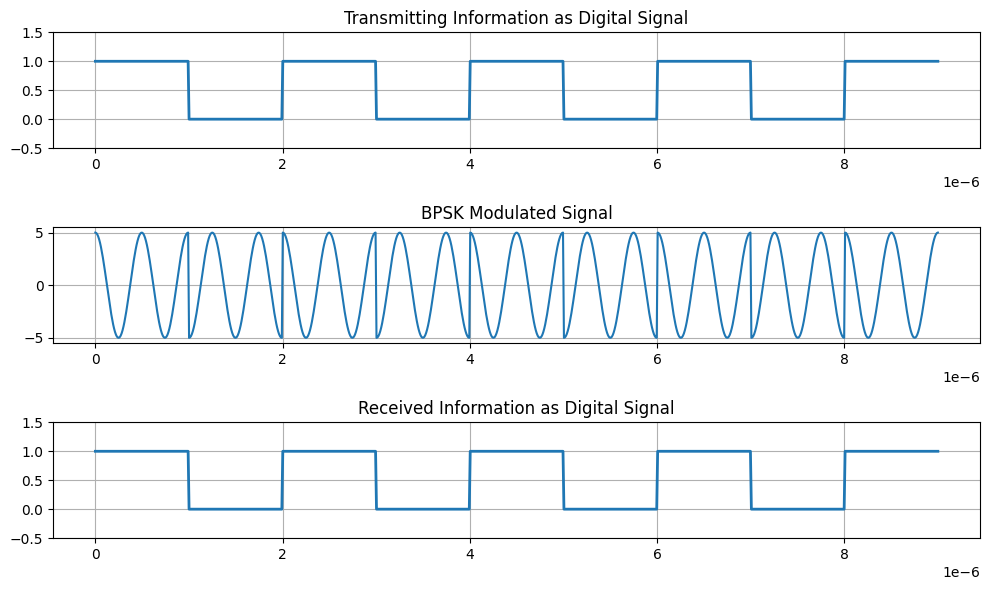

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# ── Input Binary Data ─────────────────────────────
x = np.array([1,0,1,0,1,0,1,0,1])
bp = 1e-6   # bit period

print("Binary Information at transmitter:", x)

# ── Digital Signal (Transmitter) ──────────────────
samples_per_bit = 100
bit = np.repeat(x, samples_per_bit)
t1 = np.linspace(0, bp*len(x), len(bit))

# ── BPSK Modulation ───────────────────────────────
A = 5
br = 1 / bp
f = br * 2

t_bit = np.linspace(0, bp, 100)
m = []

for b in x:
    if b == 1:
        y = A * np.cos(2*np.pi*f*t_bit)
    else:
        y = -A * np.cos(2*np.pi*f*t_bit)   # phase shift π
    m.extend(y)

m = np.array(m)
t2 = np.linspace(0, bp*len(x), len(m))

# ── BPSK Demodulation ─────────────────────────────
mn = []

for i in range(0, len(m), len(t_bit)):
    segment = m[i:i+len(t_bit)]
    carrier = np.cos(2*np.pi*f*t_bit)
    
    z = np.trapezoid(segment * carrier, t_bit)
    
    if (2*z/bp) > 0:
        mn.append(1)
    else:
        mn.append(0)

mn = np.array(mn)
print("Binary Information at Receiver:", mn)

# ── Reconstructed Digital Signal ──────────────────
bit_rec = np.repeat(mn, samples_per_bit)
t3 = np.linspace(0, bp*len(mn), len(bit_rec))

# ── Plotting ─────────────────────────────────────
plt.figure(figsize=(10,6))

plt.subplot(3,1,1)
plt.plot(t1, bit, linewidth=2)
plt.title("Transmitting Information as Digital Signal")
plt.ylim([-0.5, 1.5])
plt.grid()

plt.subplot(3,1,2)
plt.plot(t2, m)
plt.title("BPSK Modulated Signal")
plt.grid()

plt.subplot(3,1,3)
plt.plot(t3, bit_rec, linewidth=2)
plt.title("Received Information as Digital Signal")
plt.ylim([-0.5, 1.5])
plt.grid()

plt.tight_layout()
plt.show()

4. To create a program and simulate the Frequency Shift Keying (FSK) modulation technique.

Binary information at transmitter: [1 1 0 1 0 1]
Binary information at receiver: [1 1 0 1 0 1]


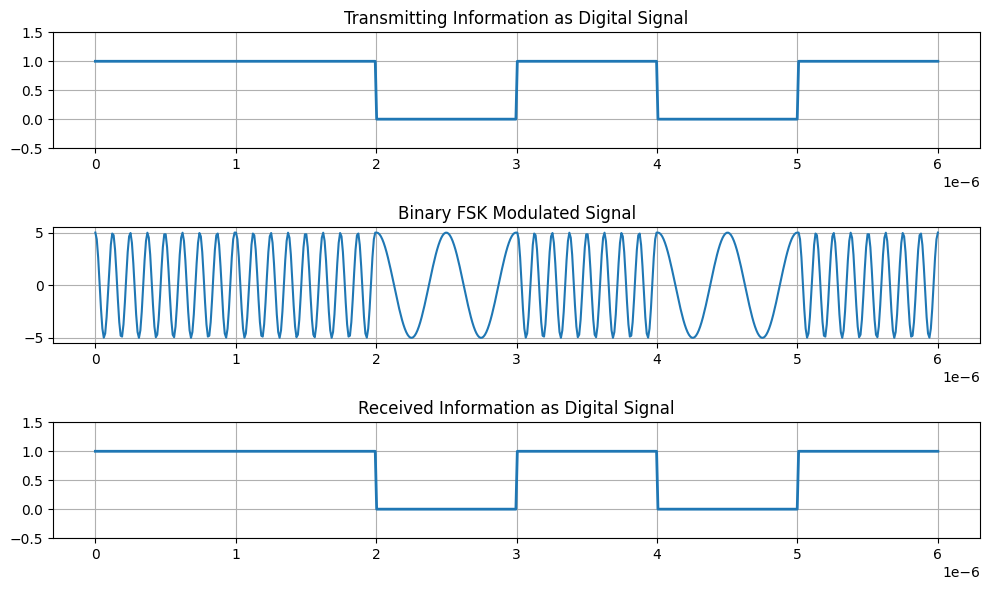

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# ── Input Binary Data ─────────────────────────────
x = np.array([1, 1, 0, 1, 0, 1])
bp = 1e-6   # bit period

print("Binary information at transmitter:", x)

# ── Digital Signal (Transmitter) ──────────────────
samples_per_bit = 100
bit = np.repeat(x, samples_per_bit)
t1 = np.linspace(0, bp*len(x), len(bit))

# ── FSK Modulation ────────────────────────────────
A = 5
br = 1 / bp
f1 = br * 8   # frequency for bit 1
f2 = br * 2   # frequency for bit 0

t_bit = np.linspace(0, bp, 100)
m = []

for b in x:
    if b == 1:
        y = A * np.cos(2*np.pi*f1*t_bit)
    else:
        y = A * np.cos(2*np.pi*f2*t_bit)
    m.extend(y)

m = np.array(m)
t2 = np.linspace(0, bp*len(x), len(m))

# ── FSK Demodulation ──────────────────────────────
mn = []

for i in range(0, len(m), len(t_bit)):
    segment = m[i:i+len(t_bit)]
    
    carrier1 = np.cos(2*np.pi*f1*t_bit)
    carrier2 = np.cos(2*np.pi*f2*t_bit)
    
    z1 = np.trapezoid(segment * carrier1, t_bit)
    z2 = np.trapezoid(segment * carrier2, t_bit)
    
    if (2*z1/bp) > (A/2):
        mn.append(1)
    else:
        mn.append(0)

mn = np.array(mn)
print("Binary information at receiver:", mn)

# ── Reconstructed Digital Signal ──────────────────
bit_rec = np.repeat(mn, samples_per_bit)
t3 = np.linspace(0, bp*len(mn), len(bit_rec))

# ── Plotting ─────────────────────────────────────
plt.figure(figsize=(10,6))

plt.subplot(3,1,1)
plt.plot(t1, bit, linewidth=2)
plt.title("Transmitting Information as Digital Signal")
plt.ylim([-0.5, 1.5])
plt.grid()

plt.subplot(3,1,2)
plt.plot(t2, m)
plt.title("Binary FSK Modulated Signal")
plt.grid()

plt.subplot(3,1,3)
plt.plot(t3, bit_rec, linewidth=2)
plt.title("Received Information as Digital Signal")
plt.ylim([-0.5, 1.5])
plt.grid()

plt.tight_layout()
plt.show()

5. To implement a program and simulate the Unipolar Non-Return-to-Zero (NRZ) signaling technique.

Generated bits: [0 0 0 0 1 0 0 0 1 1]


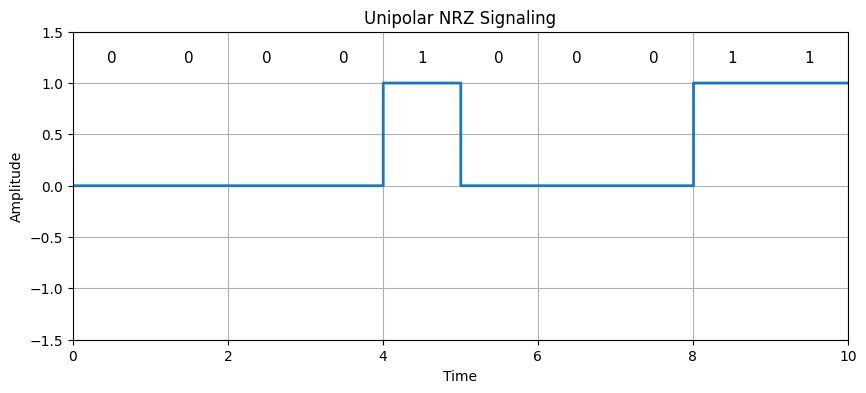

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# ── Parameters ─────────────────────────────
N = 10

# Generate random bits
n = np.random.randint(0, 2, N)
print("Generated bits:", n)

# ── Signal Generation ──────────────────────
samples_per_bit = 100
y = np.repeat(n, samples_per_bit)

# Time axis
t = np.linspace(0, N, len(y))

# ── Plot ───────────────────────────────────
plt.figure(figsize=(10,4))
plt.step(t, y, where='post', linewidth=2)

plt.xlim(0, N)
plt.ylim(-1.5, 1.5)
plt.title("Unipolar NRZ Signaling")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid()

# Show bits on top (like MATLAB figure)
for i in range(N):
    plt.text(i + 0.5, 1.2, str(n[i]), ha='center', fontsize=11)

plt.show()

6. To model a program and simulate the Polar Non-Return-to-Zero (NRZ) signaling technique.

Generated bits: [0 0 1 0 1 0 0 0 0 0]


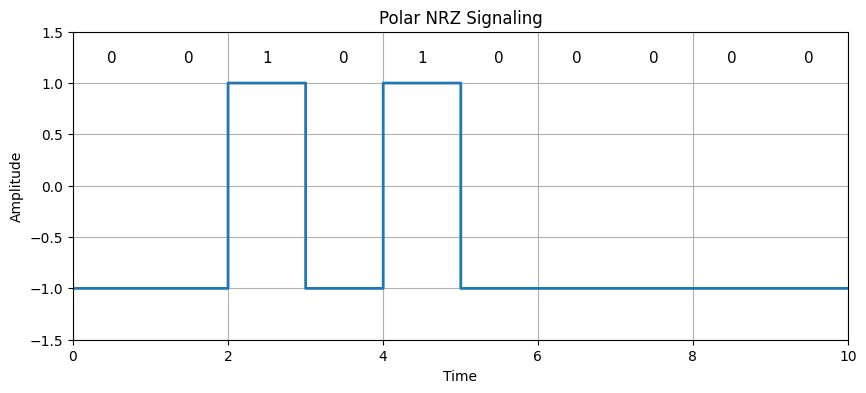

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# ── Parameters ─────────────────────────────
N = 10

# Generate random bits
n = np.random.randint(0, 2, N)
print("Generated bits:", n)

# ── Mapping (Polar NRZ: 1 → +1, 0 → -1) ──
nn = np.where(n == 1, 1, -1)

# ── Signal Generation ──────────────────────
samples_per_bit = 100
y = np.repeat(nn, samples_per_bit)

# Time axis
t = np.linspace(0, N, len(y))

# ── Plot ───────────────────────────────────
plt.figure(figsize=(10,4))
plt.step(t, y, where='post', linewidth=2)

plt.xlim(0, N)
plt.ylim(-1.5, 1.5)
plt.title("Polar NRZ Signaling")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid()

# Show bits on top (like your image)
for i in range(N):
    plt.text(i + 0.5, 1.2, str(n[i]), ha='center', fontsize=11)

plt.show()

7. To write a program and simulate the Unipolar Return-to-Zero (RZ) signaling technique.

Generated bits: [1 0 1 1 1 1 1 1 1 0]


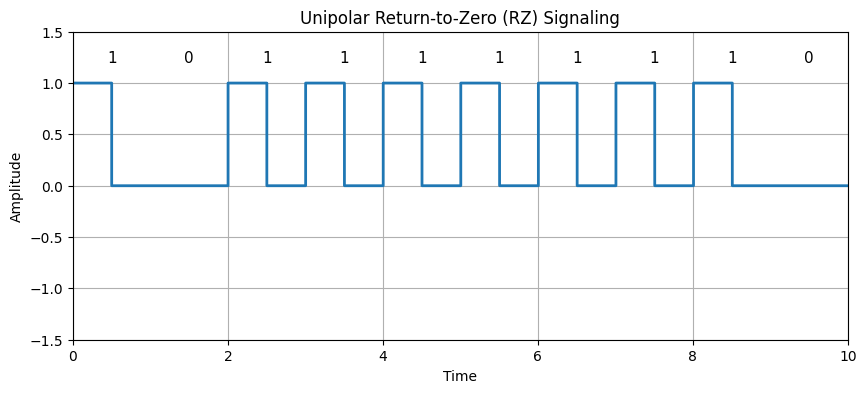

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# ── Parameters ─────────────────────────────
N = 10

# Generate random bits
n = np.random.randint(0, 2, N)
print("Generated bits:", n)

# ── Signal Generation (RZ) ─────────────────
samples_per_bit = 100
half = samples_per_bit // 2

y = []

for bit in n:
    if bit == 1:
        y.extend([1]*half + [0]*half)   # 1 → pulse then zero
    else:
        y.extend([0]*samples_per_bit)   # 0 → always zero

y = np.array(y)

# Time axis
t = np.linspace(0, N, len(y))

# ── Plot ───────────────────────────────────
plt.figure(figsize=(10,4))
plt.step(t, y, where='post', linewidth=2)

plt.xlim(0, N)
plt.ylim(-1.5, 1.5)
plt.title("Unipolar Return-to-Zero (RZ) Signaling")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid()

# Show bits on top
for i in range(N):
    plt.text(i + 0.5, 1.2, str(n[i]), ha='center', fontsize=11)

plt.show()

8. To simulate a program for the Bipolar Return-to-Zero (RZ) signaling technique.

Generated bits: [0 1 1 1 0 1 0 0 1 0]


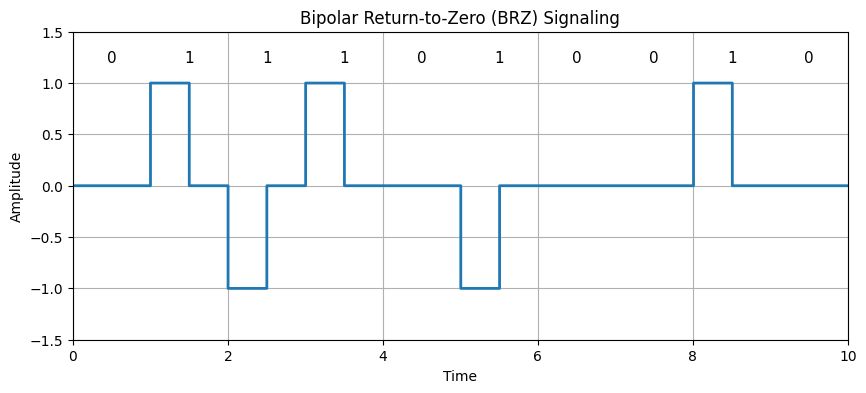

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# ── Parameters ─────────────────────────────
N = 10

# Generate random bits
n = np.random.randint(0, 2, N)
print("Generated bits:", n)

# ── Bipolar Mapping (AMI) ──────────────────
nn = np.zeros(N)
polarity = 1

for i in range(N):
    if n[i] == 1:
        nn[i] = polarity
        polarity *= -1   # alternate +1, -1
    else:
        nn[i] = 0

# ── RZ Signal Generation ───────────────────
samples_per_bit = 100
half = samples_per_bit // 2

y = []

for val in nn:
    if val != 0:
        y.extend([val]*half + [0]*half)   # pulse then zero
    else:
        y.extend([0]*samples_per_bit)     # stay zero

y = np.array(y)

# Time axis
t = np.linspace(0, N, len(y))

# ── Plot ───────────────────────────────────
plt.figure(figsize=(10,4))
plt.step(t, y, where='post', linewidth=2)

plt.xlim(0, N)
plt.ylim(-1.5, 1.5)
plt.title("Bipolar Return-to-Zero (BRZ) Signaling")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid()

# Show bits on top
for i in range(N):
    plt.text(i + 0.5, 1.2, str(n[i]), ha='center', fontsize=11)

plt.show()

9. To develop a program and simulate the Manchester (Split-Phase) coding technique.

Generated bits: [0 0 0 1 1 0 0 0 1 0]


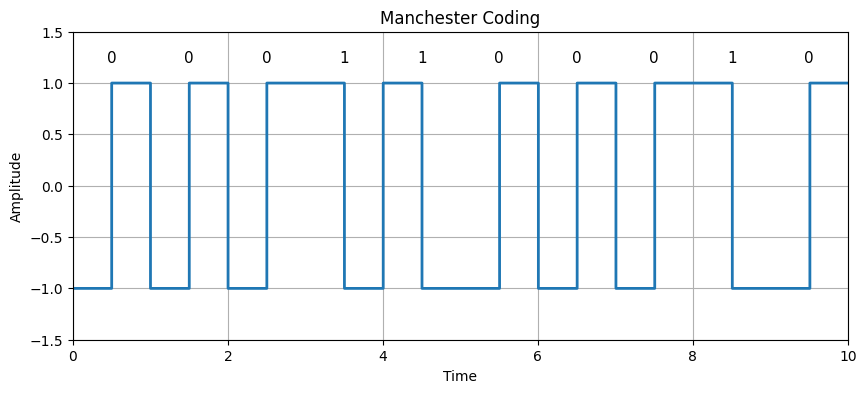

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# ── Parameters ─────────────────────────────
N = 10

# Generate random bits
n = np.random.randint(0, 2, N)
print("Generated bits:", n)

# ── Manchester Encoding ────────────────────
# 1 → [1, -1], 0 → [-1, 1]
encoded = []

for bit in n:
    if bit == 1:
        encoded.extend([1, -1])
    else:
        encoded.extend([-1, 1])

# ── Signal Generation ──────────────────────
samples_per_half_bit = 50
y = np.repeat(encoded, samples_per_half_bit)

# Time axis
t = np.linspace(0, N, len(y))

# ── Plot ───────────────────────────────────
plt.figure(figsize=(10,4))
plt.step(t, y, where='post', linewidth=2)

plt.xlim(0, N)
plt.ylim(-1.5, 1.5)
plt.title("Manchester Coding")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid()

# Show bits on top
for i in range(N):
    plt.text(i + 0.5, 1.2, str(n[i]), ha='center', fontsize=11)

plt.show()